# Lab 5: Plotting SST in Python

**Learning Objectives**
By the end of this lab, you should be able to 
1. Find and download SST data
2. Describe the structure of a netCDF file
3. Plot a time series of SST from data in a netCDF file
4. Plot a map of SST and SST differencs from a netCDF file

## Motivation

Upwelling in the California Current System

## Part 1: Obtaining SST Data from the MUR Product

In this lab, we'll access data from the Multi-scale Ultra-high Resolution (MUR) Sea Surface Temperature (SST) product. This product is supported by the NASA MEaSUREs program dn more information can be found at this project on the product page at [JPL's Physical Oceanography DAAC](https://podaac.jpl.nasa.gov/MEaSUREs-MUR).

Here, we will use a convenient tool from the Environmental Research Division's Data Access Program (ERRDAP) to gather SST data in a given location over a specific time frame. For the MUR product, we can access the data [HERE](https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41.graph?analysed_sst%5B(2024-11-04T09:00:00Z)%5D%5B(-89.99):(89.99)%5D%5B(-179.99):(180.0)%5D&.draw=surface&.vars=longitude%7Clatitude%7Canalysed_sst&.colorBar=%7C%7C%7C%7C%7C&.bgColor=0xffccccff&.click=?281,381).

Navigate to this page and select a subset of data according to the following specifications:
- `time`: 2008-02-01T09:00:00Z to 2008-07-31T09:00:00Z
- `latitude`: 34°N to 41°N
- `longitude` -126°E to -118°E
- `analysed_sst` (checked)

From the dropdown of output file types, choose the `.nc` option.

On ERRDAP, your query should look like the following screenshot:

```{figure} ../images/labs/lab05/mur_errdap.png
---
height: 400px
name: errdap-screenshot
---
Screenshot of a data request from ERRDAP for the MURv4.1 data around Monterey Bay during spring 2008.
```

When the file downloads, save it into your Lab 5/Data folder. Then, to facilitate the codes below, enter the path to your data folder into the following coding block:

In [11]:
data_dir = '../data/'

Note that this query might take a bit of time to process - in testing this notebook, the query took about 15 minutes. Note also that the file is a little more than 800 MB in size.

### Understanding the structure of a netCDF file

The netCDF file structure - short for Common Data Format - is an organizational structure for vector data used widely in oceanography and other Earth sciences. To explore this file, open the file with the Panoply and take a look at the contents.

You should see the following fields:
- analysed_sst
- longitude
- latitude
- time

```{figure} ../images/labs/lab05/mur_panoply.png
---
height: 200px
name: mur-panoply
---
MUR in Panoply
```

Of course, these match up with all of the fields selected from the ERRDAP portal. Here, we see that the `.nc` file contains the full collection of complementary fields.

By clicking each field in the file list, you can see lots of metadata about each field and, importantly, its size. For example, you can see that the `analysed_sst` field has a shape of (182, 701, 801) corresponding to the dimensions of time, latitude, and longitude. You can visualize this as a 3D grid composed of 2D maps stacked through time:

```{figure} ../images/labs/lab05/mur_file_organization.png
---
height: 400px
name: nc_organization
---
The structure of the SST data in the MUR file
```

## Part 2: Reading netCDF data in Python 

### Loading Packages in Python
Before reading in our data for plotting, we'll need to load in a few packages. While Python has some default-in, built-in functionality, the code for specific tasks such as reading and plotting data are contained in packages. Here, we will *import* some packages used in this notebook. 

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc4
from datetime import datetime

Typically, we will import packages at the start of a notebook but they are put here near the code for this initial example.

### Reading NetCDF files
In Python, the `netCDF` package prodvides the functionality to read in `nc` files. For example, we can read in the files into a data set object and print out the names of the variables as follows:

In [13]:
# read in the SST nc file
ds = nc4.Dataset(os.path.join(data_dir,'MUR_SST.nc'))

# print out the variable names
print(ds.variables.keys())

dict_keys(['time', 'latitude', 'longitude', 'analysed_sst'])


Here, we see that the variables are the same as those above. We can read in the data from the file as follows:

In [14]:
time = ds.variables['time'][:]
longitude = ds.variables['longitude'][:]
latitude = ds.variables['latitude'][:]
sst = ds.variables['analysed_sst'][:,:,:]

In the fields above, we can see that they are read in with their shape in mind - the 1D fields are appended with the `[:]` field while the 3D fields are appended with `[:,:,:]`.

After reading in the fields, we'll be sure to close the file:

In [15]:
ds.close()

```{note}
If you've been following along with these labs from the previous ones on QGIS, one horizontal slice of this file can be thought of like a raster file.
```

## Part 3: Plotting a Time Series

Now that we've got our data read in, we're read for some plotting. Since the goal of this exploration is to examine the effect of upwelling on SST, let's have a look at a timeseries of temperature in the middle of Monterey Bay at 36.75°N, 122.03°W.

In order to make a time series at this location, we'll need to find its location in the grid. Here, we'll find the closest indices in the longitude and latitude grids that correspond to the Monterey Bay location. Let's define this here:

In [18]:
# define the location of Monterey Bay
monterey_bay_lon = -122.03
monterey_bay_lat = 36.75

# get the indices of these locations in the longitude and latitude grid
lon_index = np.argmin(np.abs(longitude-monterey_bay_lon))
lat_index = np.argmin(np.abs(latitude-monterey_bay_lat))

# print the indices
print('Longitude Index:',lon_index)
print('Latitude Index:',lat_index)

Longitude Index: 397
Latitude Index: 275


With these indices in hand, we can sample the big 3D grid along the respective dimensions. Above, we saw that latitude corresponded to dimension 1 and longitude corredponded to dimension 2, so we'll enter these here:

In [19]:
sst_monterey_bay = sst[:, lat_index, lon_index]

The `:` in dimension 0 indicates that we will take all values along this dimension i.e. all times.

With this data in hand, we can make a plot of the timeseries:

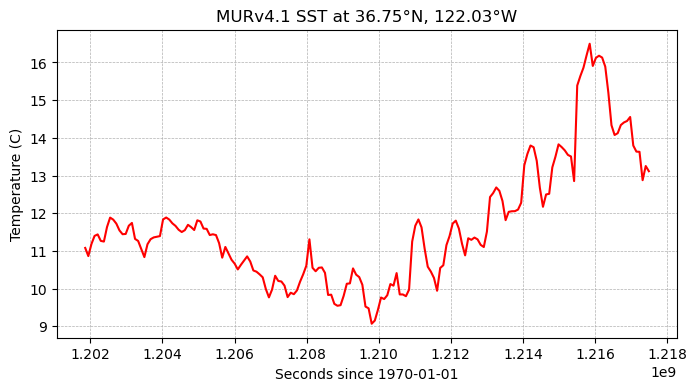

In [27]:
# make a figure object
fig = plt.figure(figsize=(8,4))

# plot the time series
plt.plot(time, sst_monterey_bay, color='red')

# label the axes 
plt.ylabel('Temperature (C)')
plt.xlabel('Seconds since 1970-01-01')
plt.grid(linestyle='--', linewidth=0.5)
plt.title(f'MURv4.1 SST at {latitude[lat_index]:.2f}°N, {-longitude[lon_index]:.2f}°W')

# show the plot
plt.show()

In the plot above, we see that the time was labeled as "Seconds since 1970-01-01" and this was labeled in the metadata in the nc file. This type of time, called *Unix time*, is convenient for storing time in a continuous format but it's not very helpful for human interpretation. Luckily, there is a convenient function that can be used to convert each Unix time to a date. Let's do that there here:

In [26]:
dates = [] # make an empty list to hold some dates 

# loop through each Unix time
for t in time:

    # convert the Unix time to a date
    date = datetime.fromtimestamp(t)

    # put the date in the dates list
    dates.append(date)

With our dates in hand, we can recreate the plot above:

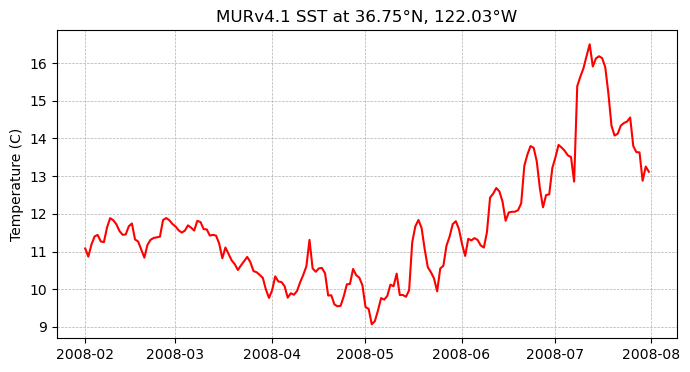

In [28]:
fig = plt.figure(figsize=(8,4))
plt.plot(dates, sst_monterey_bay, color='red')
plt.ylabel('Temperature (C)')
plt.grid(linestyle='--', linewidth=0.5)
plt.title(f'MURv4.1 SST at {latitude[lat_index]:.2f}°N, {-longitude[lon_index]:.2f}°W')
plt.show()

With our converted dates, we can see that the monthly values in 2008 are used for x-axis ticks in our new plot, consistent with the query from ERRDAP.

## Plotting a Map

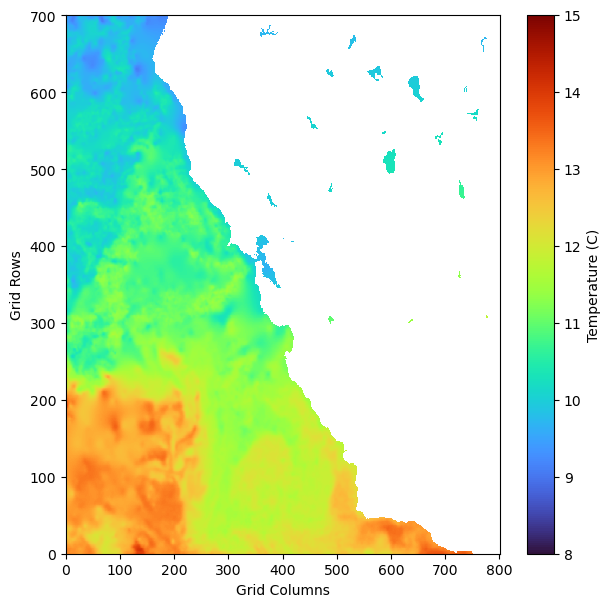

In [46]:
plt.figure(figsize=(7,7))
C = plt.pcolormesh(sst[0,:,:],cmap='turbo',vmin=8,vmax=15)
plt.colorbar(C, label='Temperature (C)')
plt.xlabel('Grid Columns')
plt.ylabel('Grid Rows')
plt.show()

In [1]:
plt.figure(figsize=(7,7))
C = plt.pcolormesh(longitude, latitude, sst[81,:,:],cmap='turbo',vmin=8,vmax=15)
plt.colorbar(C)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

NameError: name 'plt' is not defined

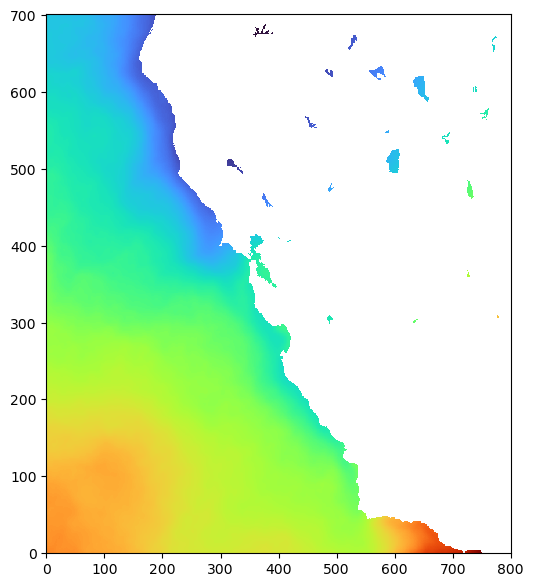

In [29]:
mean_sst = np.mean(sst, axis=0)

plt.figure(figsize=(6,7))
plt.pcolormesh(mean_sst,cmap='turbo')
plt.show()

## Plotting a Map

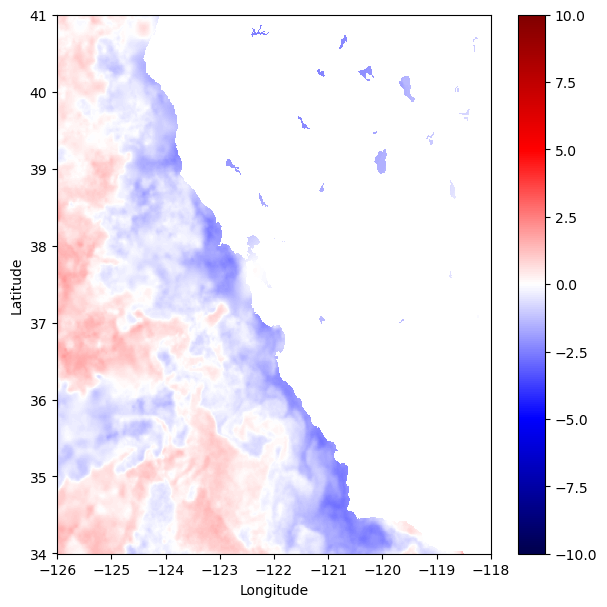

In [48]:
difference = sst[81,:,:]-sst[0,:,:]
max_difference = 10#np.max(np.abs(anomaly))

plt.figure(figsize=(7,7))
C = plt.pcolormesh(longitude, latitude, difference,
                   cmap='seismic', vmin=-max_difference, vmax=max_difference)
plt.colorbar(C)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [10]:
anomaly = sst[81,:,:]-np.mean(sst,axis=0)
max_anomaly = 10#np.max(np.abs(anomaly))

plt.figure(figsize=(7,7))
C = plt.pcolormesh(anomaly, cmap='seismic', vmin=-max_anomaly, vmax=max_anomaly)
plt.colorbar(C)
plt.show()

NameError: name 'sst' is not defined

## &#129300; Try it for yourself!

In the example above, we looked at upwelling in the California Current system during spring of 2008 - only a small part of the decades-long global MUR SST product. Consider another process in the ocean that you expect to have a significant SST signal - think ENSO events, marine heat waves, ice sheet melt, etc. Then, using the steps above, find some data from the MURv4.2 product and use it to examine your process of interest.